In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
sfreq = 64
paradigm = P300(resample=sfreq, tmin=0, tmax=0.8, fmin=0.1, fmax=32)
dataset = BNCI2014009()
subject, session, run = 1, "session_0", "run_0"

#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"


In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Not setting metadata
576 matching events found
No baseline correction applied


Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.797 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


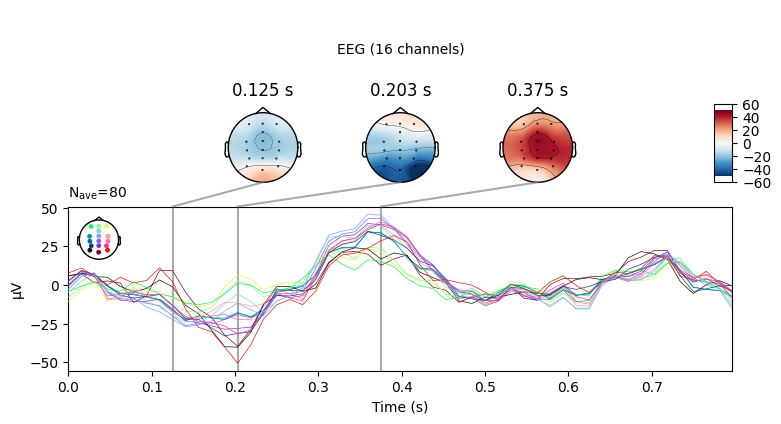

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
tmin = epochs.tmin
sfreq = epochs.info['sfreq']

def hankel_tensor(X, y=None):    
    window = .4
    max_lag = .4
    
    n_epochs, n_channels, _ = X.shape
    roi0 = int((0 - tmin)*sfreq)
    roi1 = int((window - tmin)*sfreq)
    n_times = roi1-roi0
    n_lags= int(max_lag*sfreq)
    Xt = np.zeros((n_epochs, n_channels, n_times, n_lags))
    for l in range(n_lags):
        Xt[:,:,:,l] = X[:,:,roi0+l:roi1+l]
    return Xt

In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from mne.decoding import Scaler

tl.set_backend('cupy')


X = epochs.get_data(picks='eeg')
split = len(epochs)//2
X_train = X[:split]
X_test = X[split:]
y_train = labels[:split]
y_test = labels[split:]


scaler = Scaler(scalings='mean', with_mean=False)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = tl.tensor(hankel_tensor(X_train))
X_test = tl.tensor(hankel_tensor(X_test))

In [8]:
hoda = HODA(
    max_iter=128,
    rank=(2,2,2),
    tol=1e-6,
    initialize ='svd',
    verbose=True,
    shrinkage=('oas', 'oas', 'oas'),
    toeplitz=(1,2),
    solver='ratio_svd'
)
#%lprun -f hoda.fit hoda.fit(X_train,y_train)
hoda.fit(X_train,y_train)

[0/128]  shrinkage=0.0091  shrinkage=0.0227  shrinkage=0.0227  step=2.0232e+00
[1/128]  shrinkage=0.0095  shrinkage=0.0453  shrinkage=0.0453  step=1.3071e+00
[2/128]  shrinkage=0.0091  shrinkage=0.0281  shrinkage=0.0281  step=1.5072e+00
[3/128]  shrinkage=0.0105  shrinkage=0.0634  shrinkage=0.0634  step=2.0834e+00
[4/128]  shrinkage=0.0091  shrinkage=0.0273  shrinkage=0.0273  step=2.1069e+00
[5/128]  shrinkage=0.0106  shrinkage=0.0595  shrinkage=0.0595  step=1.9764e+00
[6/128]  shrinkage=0.0093  shrinkage=0.0313  shrinkage=0.0313  step=1.9343e+00
[7/128]  shrinkage=0.0101  shrinkage=0.0603  shrinkage=0.0603  step=1.9162e+00
[8/128]  shrinkage=0.0094  shrinkage=0.0311  shrinkage=0.0311  step=1.9422e+00
[9/128]  shrinkage=0.0097  shrinkage=0.0485  shrinkage=0.0485  step=1.9810e+00
[10/128]  shrinkage=0.0095  shrinkage=0.0347  shrinkage=0.0347  step=1.9838e+00
[11/128]  shrinkage=0.0096  shrinkage=0.0365  shrinkage=0.0365  step=1.8893e+00
[12/128]  shrinkage=0.0097  shrinkage=0.0411  shri

[104/128]  shrinkage=0.0091  shrinkage=0.0250  shrinkage=0.0250  step=1.8649e+00
[105/128]  shrinkage=0.0100  shrinkage=0.0655  shrinkage=0.0655  step=1.9337e+00
[106/128]  shrinkage=0.0091  shrinkage=0.0265  shrinkage=0.0265  step=1.8605e+00
[107/128]  shrinkage=0.0109  shrinkage=0.0766  shrinkage=0.0766  step=1.9312e+00
[108/128]  shrinkage=0.0091  shrinkage=0.0256  shrinkage=0.0256  step=2.0020e+00
[109/128]  shrinkage=0.0112  shrinkage=0.0837  shrinkage=0.0837  step=1.9613e+00
[110/128]  shrinkage=0.0092  shrinkage=0.0284  shrinkage=0.0284  step=1.4609e+00
[111/128]  shrinkage=0.0115  shrinkage=0.0965  shrinkage=0.0965  step=1.0878e+00
[112/128]  shrinkage=0.0092  shrinkage=0.0272  shrinkage=0.0272  step=1.0852e+00
[113/128]  shrinkage=0.0124  shrinkage=0.1315  shrinkage=0.1315  step=1.2110e+00
[114/128]  shrinkage=0.0092  shrinkage=0.0258  shrinkage=0.0258  step=1.2269e+00
[115/128]  shrinkage=0.0126  shrinkage=0.1272  shrinkage=0.1272  step=1.6095e+00
[116/128]  shrinkage=0.0091 

HODA(max_iter=128, rank=(2, 2, 2), shrinkage=('oas', 'oas', 'oas'),
     solver='ratio_svd', toeplitz=(1, 2), tol=1e-06, verbose=True)

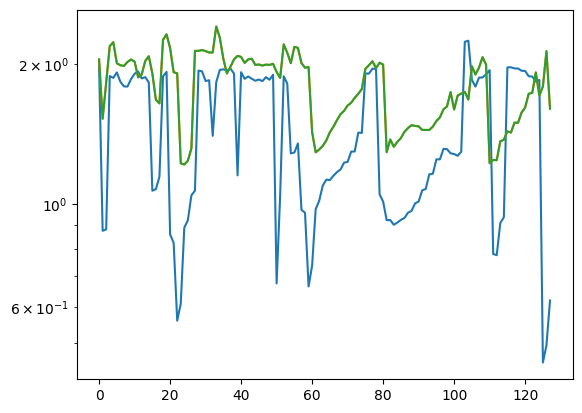

In [9]:
import cupy

plt.semilogy(cupy.asnumpy(hoda.updates_[:,:hoda.iter_]))
plt.show()

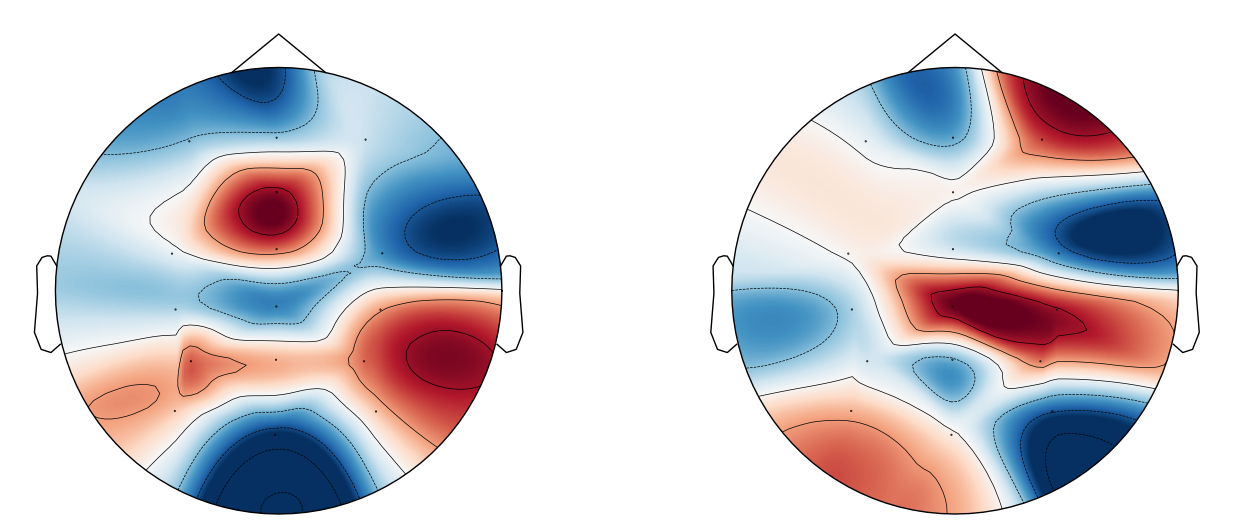

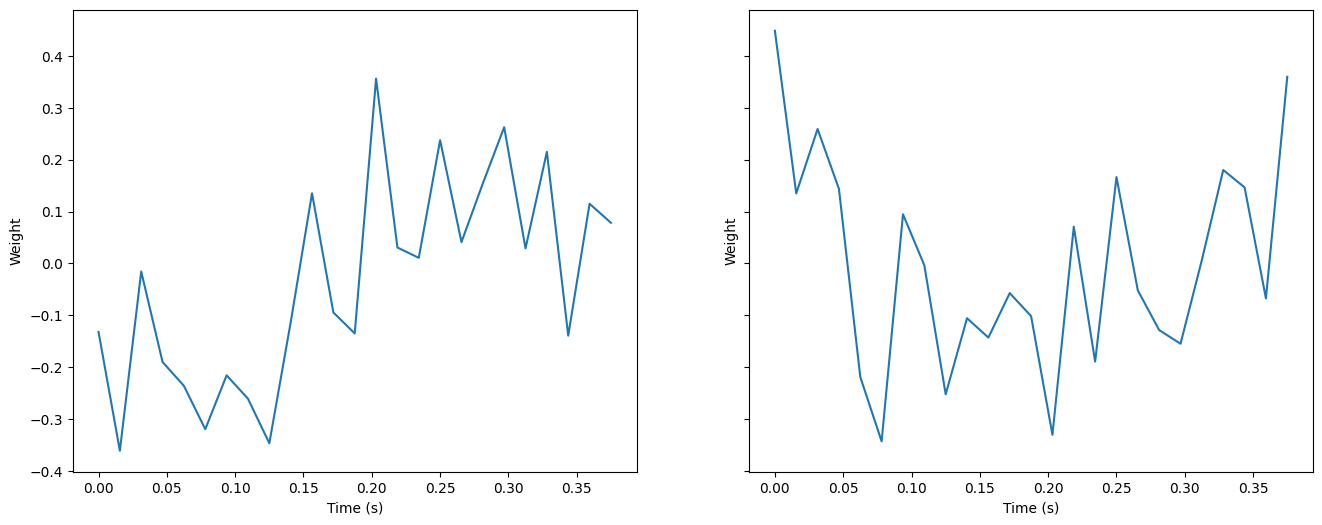

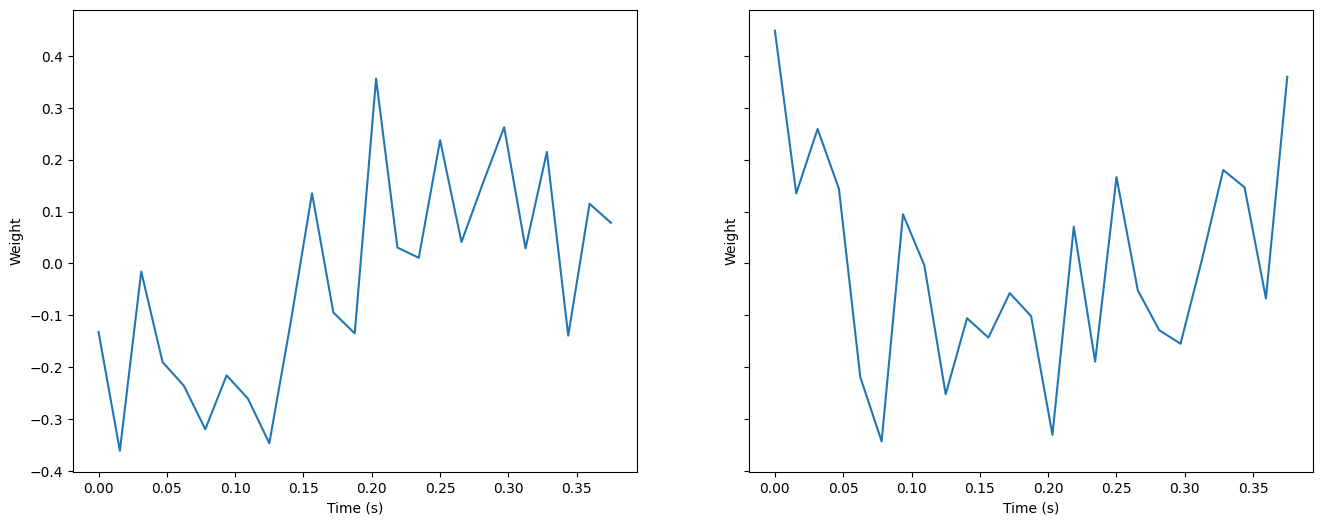

In [10]:
fig, axs = plt.subplots(1,hoda.rank_[0], figsize=(16,6))
for i in range(hoda.rank_[0]):
    w = cupy.asnumpy(hoda.projs_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[i], show=False)

fig, axs = plt.subplots(1,hoda.rank_[1], figsize=(16,6), sharey=True)
vmax = np.max(np.abs(hoda.projs_[1]))
for i in range(hoda.rank_[1]):
    w = cupy.asnumpy(hoda.projs_[1][:,i])
    axs[i].plot(epochs.times[:len(w)], w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')

    
fig, axs = plt.subplots(1,hoda.rank_[2], figsize=(16,6), sharey=True)
for i in range(hoda.rank_[2]):
    w = cupy.asnumpy(hoda.projs_[2][:,i])
    axs[i].plot(epochs.times[:len(w)], w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')


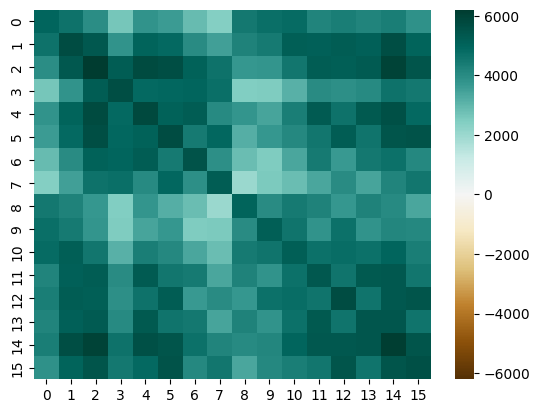

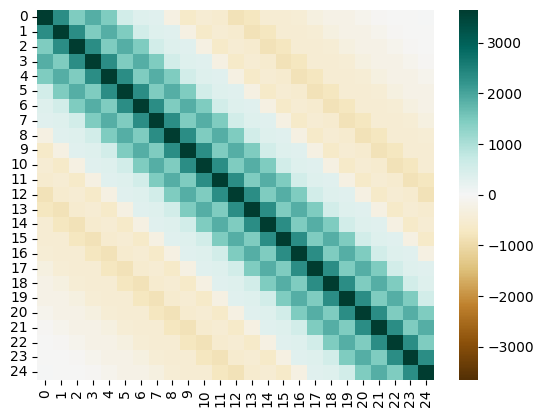

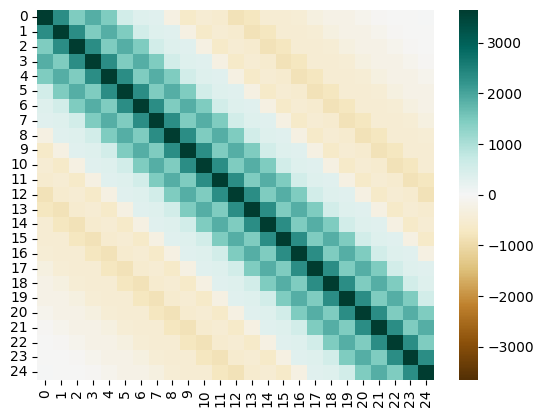

In [11]:
for k in range(3):
    cov = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(cov))
    _ = sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    _ = plt.show()

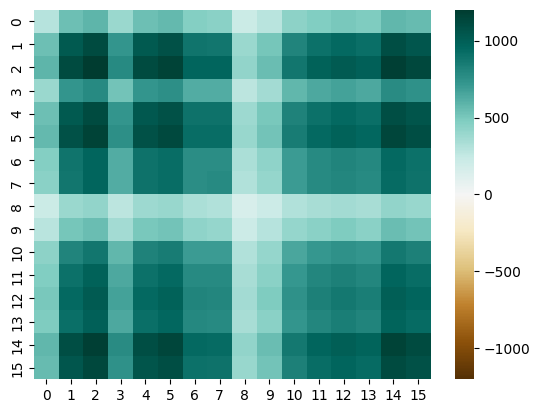

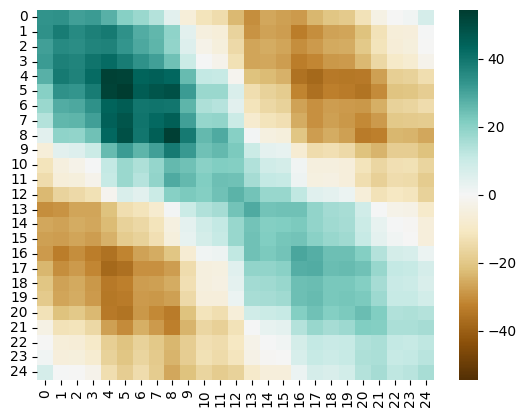

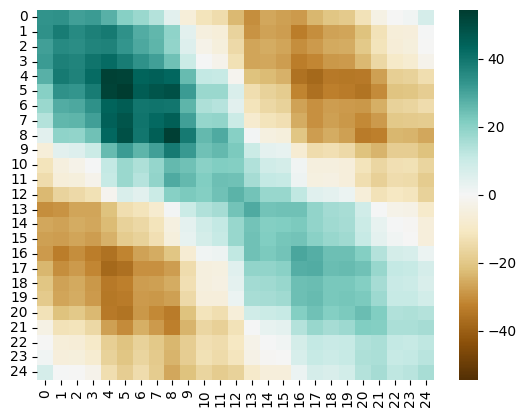

In [12]:
for k in range(3):
    cov = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

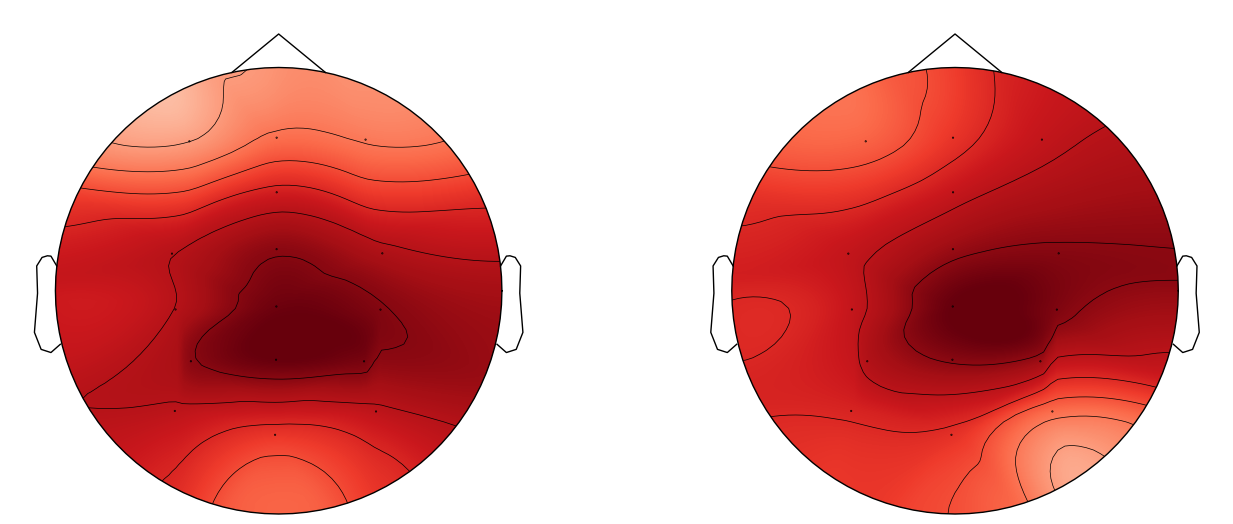

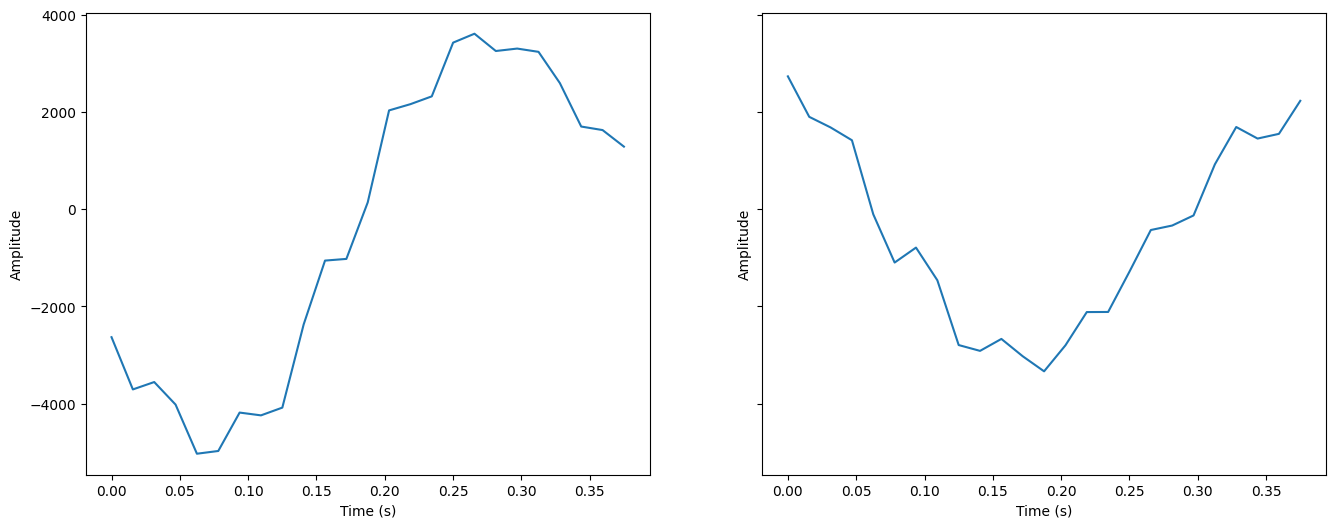

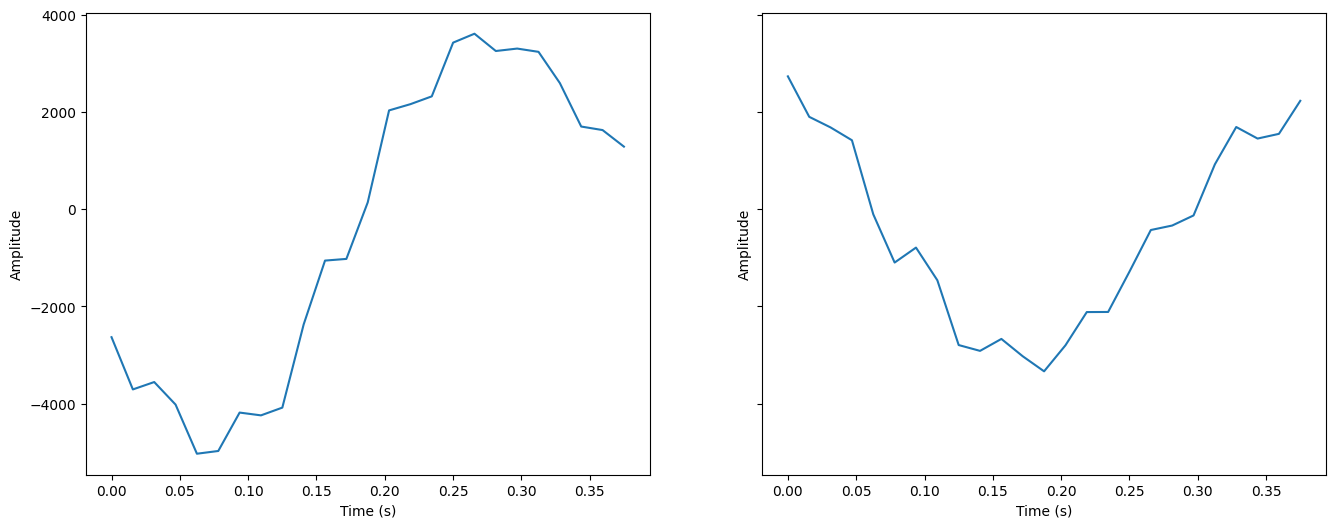

In [13]:
patterns = [hoda.scatter_w_[k] @ p for k,p in enumerate(hoda.projs_)]


fig, axs = plt.subplots(1,hoda.rank_[0], figsize=(16,6))
for i in range(hoda.rank_[0]):
    w = cupy.asnumpy(patterns[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[i], show=False)

fig, axs = plt.subplots(1,hoda.rank_[1], figsize=(16,6), sharey=True)
vmax = np.max(np.abs(patterns[1]))
for i in range(hoda.rank_[1]):
    w = cupy.asnumpy(patterns[1][:,i])
    axs[i].plot(epochs.times[:len(w)], w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Amplitude')

    
fig, axs = plt.subplots(1,hoda.rank_[2], figsize=(16,6), sharey=True)
for i in range(hoda.rank_[2]):
    w = cupy.asnumpy(patterns[2][:,i])
    axs[i].plot(epochs.times[:len(w)], w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Amplitude')


In [14]:

Xt_train = cupy.asnumpy(hoda.transform(X_train))
Xt_test = cupy.asnumpy(hoda.transform(X_test))


tril_idc = np.tril_indices(2)

Xt_train_tri = np.zeros((*Xt_train.shape[:2], len(tril_idc[0])))
for i in range(Xt_train_tri.shape[0]):
    for c in range(Xt_train_tri.shape[1]):
        Xt_train_tri[i,c] = Xt_train[i,c][tril_idc]
Xt_train = Xt_train_tri.reshape((Xt_train_tri.shape[0],-1))
        
Xt_test_tri = np.zeros((*Xt_test.shape[:2], len(tril_idc[0])))
for i in range(Xt_test_tri.shape[0]):
    for c in range(Xt_test_tri.shape[1]):
        Xt_test_tri[i,c] = Xt_test[i,c][tril_idc]
Xt_test = Xt_test_tri.reshape((Xt_test_tri.shape[0],-1))


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)

LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')

In [16]:
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()
f1 = feature_order[0]
f2 = feature_order[1]

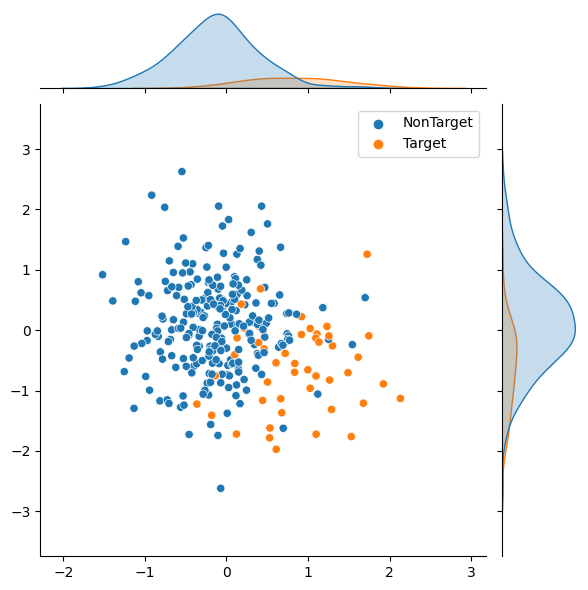

In [17]:
import seaborn as sns

g = sns.jointplot(x=Xt_train[:,f1],y=Xt_train[:,f2], hue=y_train)

In [18]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.9506944444444444

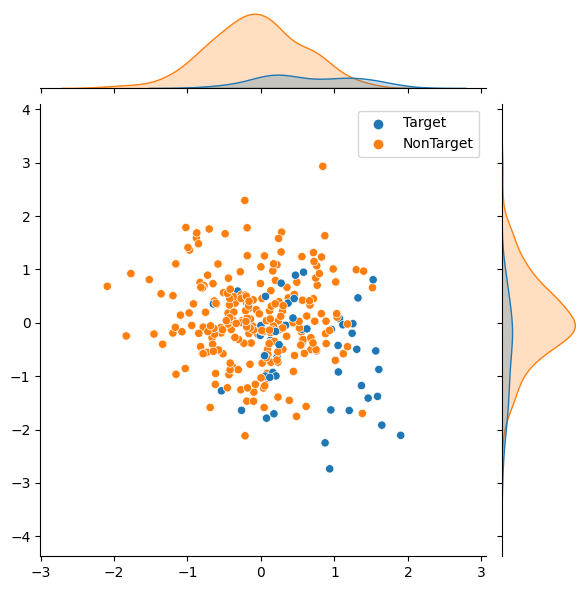

In [19]:
g = sns.jointplot(x=Xt_test[:,f1],y=Xt_test[:,f2], hue=y_test)

In [20]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.8873263888888889